# CFG Heuristic vs GED Comparison

This notebook visualizes the difference between the heuristic CFG distance and the CFG edit distance (GED).
It also reports agreement rate, Pearson correlation, and Spearman correlation for the paired distances.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

project_root = Path(os.getenv("PROJECT_ROOT_DIR"))
csv_path = project_root / "dataset" / "results" / "cfg_heuristic_vs_ged.csv"

df = pd.read_csv(csv_path)
df = df.sort_values(["file_hash", "code_object"]).reset_index(drop=True)
df["distance_delta"] = df["heuristic_cfg_distance"] - df["ged_cfg_distance"]
df.head()

,file_hash,source,gt_pyc,derived_pyc,code_object,gt_name,derived_name,gt_inst_count,derived_inst_count,gt_block_count,derived_block_count,gt_block_edge_count,derived_block_edge_count,instruction_distance,normalized_instruction_distance,equivalent_cfg,heuristic_cfg_distance,ged_cfg_distance,distance_delta
0,0003cc17c0694ad2a64411aa891571da06fa91039926de...,PyPi,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,<module>,<module>,<module>,114,114,1,1,0,0,0,0.000000,True,0,0,0
1,0003cc17c0694ad2a64411aa891571da06fa91039926de...,PyPi,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,<module>.PrivateLinkResourcesOperations,<module>.PrivateLinkResourcesOperations,<module>.PrivateLinkResourcesOperations,36,36,1,1,0,0,0,0.000000,True,0,0,0
2,0003cc17c0694ad2a64411aa891571da06fa91039926de...,PyPi,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,<module>.PrivateLinkResourcesOperations.__init__,<module>.PrivateLinkResourcesOperations.__init__,<module>.PrivateLinkResourcesOperations.__init__,61,61,12,12,14,14,0,0.000000,True,0,0,0
3,0003cc17c0694ad2a64411aa891571da06fa91039926de...,PyPi,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,<module>.PrivateLinkResourcesOperations.list,<module>.PrivateLinkResourcesOperations.list,<module>.PrivateLinkResourcesOperations.list,135,136,11,11,13,13,2,0.014706,True,0,0,0
4,000637e3672e0ec68d9852c2f5a5b8bdb0abea256c904b...,PyPi,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,<module>,<module>,<module>,171,171,1,1,0,0,0,0.000000,True,0,0,0


In [2]:
def pearson(xs, ys):
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    if len(xs) < 2 or len(xs) != len(ys):
        return np.nan
    sx = xs.std(ddof=0)
    sy = ys.std(ddof=0)
    if sx == 0 or sy == 0:
        return np.nan
    return float(np.corrcoef(xs, ys)[0, 1])


def average_ranks(values):
    values = list(values)
    indexed = sorted(enumerate(values), key=lambda item: item[1])
    ranks = [0.0] * len(values)
    start = 0
    while start < len(indexed):
        end = start
        while end < len(indexed) and indexed[end][1] == indexed[start][1]:
            end += 1
        avg_rank = (start + end - 1) / 2 + 1
        for idx in range(start, end):
            ranks[indexed[idx][0]] = avg_rank
        start = end
    return np.asarray(ranks, dtype=float)


def spearman(xs, ys):
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    if len(xs) < 2 or len(xs) != len(ys):
        return np.nan
    return pearson(average_ranks(xs), average_ranks(ys))


heuristic = df["heuristic_cfg_distance"].astype(float)
ged = df["ged_cfg_distance"].astype(float)
delta = heuristic - ged

agreement_rate = float((heuristic == ged).mean()) if len(df) else np.nan
pearson_corr = pearson(heuristic, ged)
spearman_corr = spearman(heuristic, ged)

summary = pd.DataFrame(
    {
        "agreement_rate": [agreement_rate],
        "pearson_correlation": [pearson_corr],
        "spearman_correlation": [spearman_corr],
        "rows": [len(df)],
        "heuristic_mean": [heuristic.mean()],
        "ged_mean": [ged.mean()],
        "delta_mean": [delta.mean()],
    }
)
summary

,agreement_rate,pearson_correlation,spearman_correlation,rows,heuristic_mean,ged_mean,delta_mean
0,0.968775,0.906581,0.998101,30392,1.104666,0.673598,0.431067


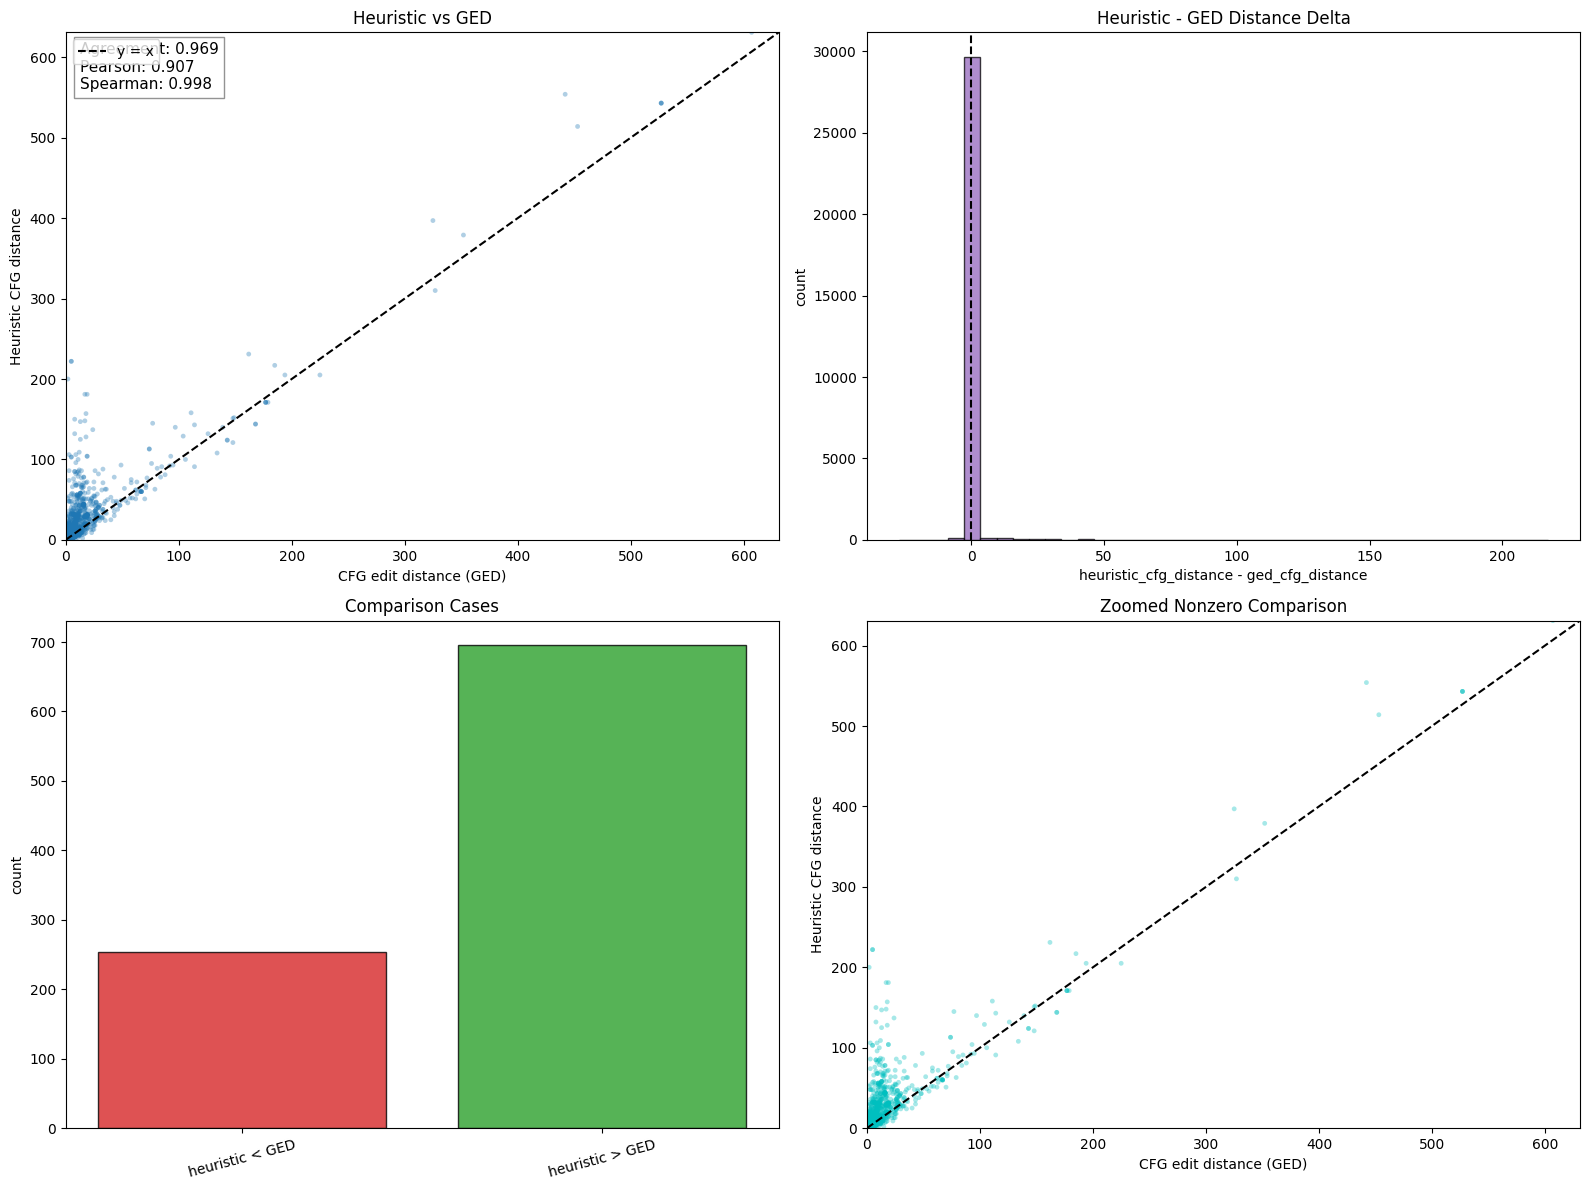

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Scatter: heuristic vs GED
ax = axes[0, 0]
ax.scatter(ged, heuristic, s=12, alpha=0.35, color="tab:blue", edgecolors="none")
lims = [min(ged.min(), heuristic.min()), max(ged.max(), heuristic.max())]
ax.plot(lims, lims, linestyle="--", color="black", linewidth=1.5, label="y = x")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("CFG edit distance (GED)")
ax.set_ylabel("Heuristic CFG distance")
ax.set_title("Heuristic vs GED")
ax.legend(loc="upper left")
ax.text(
    0.02,
    0.98,
    f"Agreement: {agreement_rate:.3f}\nPearson: {pearson_corr:.3f}\nSpearman: {spearman_corr:.3f}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray"),
)

# Delta histogram
ax = axes[0, 1]
ax.hist(delta, bins=40, color="tab:purple", alpha=0.75, edgecolor="black")
ax.axvline(0, color="black", linestyle="--", linewidth=1.5)
ax.set_title("Heuristic - GED Distance Delta")
ax.set_xlabel("heuristic_cfg_distance - ged_cfg_distance")
ax.set_ylabel("count")

# Agreement / disagreement counts
ax = axes[1, 0]
labels = ["heuristic < GED", "heuristic > GED"]
counts = [int((heuristic < ged).sum()),  int((heuristic > ged).sum())]
colors = ["tab:red", "tab:green"]
ax.bar(labels, counts, color=colors, alpha=0.8, edgecolor="black")
ax.set_title("Comparison Cases")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=15)

# Zoomed overlay on the nonzero region
ax = axes[1, 1]
nonzero = df[(df["heuristic_cfg_distance"] > 0) | (df["ged_cfg_distance"] > 0)].copy()
if len(nonzero) > 0:
    ax.scatter(nonzero["ged_cfg_distance"], nonzero["heuristic_cfg_distance"], s=12, alpha=0.35, color="c", edgecolors="none")
    lims2 = [0, max(nonzero["ged_cfg_distance"].max(), nonzero["heuristic_cfg_distance"].max())]
    ax.plot(lims2, lims2, linestyle="--", color="black", linewidth=1.5)
    ax.set_xlim(lims2)
    ax.set_ylim(lims2)
ax.set_title("Zoomed Nonzero Comparison")
ax.set_xlabel("CFG edit distance (GED)")
ax.set_ylabel("Heuristic CFG distance")

plt.tight_layout()
plt.show()